In [ ]:
import os
import numpy as np
from dataclasses import replace

from model import *

result_folder = "./media/"
os.makedirs(result_folder, exist_ok=True)

# Quickstart

In [ ]:
# Set random seed for reproducibility
np.random.seed(1)

# Define model parameters
mu = 6e-03              # inertia
eta0 = 2.2              # thermal noise amplitude
eta1 = 9.0              # active noise amplitude
k_s1 = 3.5              # sarcomere stiffness constant 1
k_s2 = 3.0             # sarcomere stiffness constant 2
u_s = 1e-01             # sarcomere-level friction
f_s0 = -7.7e-01         # force-velocity relation coeff 0
f_s1 = -5.8e-02         # force-velocity relation coeff 1
f_s2 = 1.e-01           # force-velocity relation coeff 2
f_s3 = 1.2e-02          # force-velocity relation coeff 3


# Create base model parameters using dataclass
model_params = model.ModelParams(
    N=20,  # number sarcomeres
    mu=mu,  # inertia
    eta=[eta0, eta1],  # noise amplitudes (thermal and active)
    k_l=None,  # stiffness constant of load (will be set per condition)
    k_s=[k_s1, k_s2],  # stiffness constants of sarcomere
    u_s=u_s,  # sarcomere-level friction
    o_s=None,  # parameters of length-dependent force (filament overlap)
    f_s=[f_s0, f_s1, f_s2, f_s3],  # force-velocity relation
    h=0.0,  # static force inhomogeneity (STD of normal dist)
)

# Create simulation parameters using dataclass
sim_params = model.SimParams(
    y0=None,  # initial conditions of model
    t1=5,  # duration of simulation
    dt=0.002,  # simulation time step
    a_mode='sine',  # activation mode
    a=[1, 0.0, 1],  # activation frequency, baseline and amplitude
    p=0,  # prestrain
)

# Create soft model (k_l = 0.5)
model_params_soft = replace(model_params, k_l=0.5)
model_soft = model.Model(model_params_soft, sim_params, folder=result_folder, autosave=False)
model_soft.integrate()
model_soft.analyze()

# Create intermediate model (k_l = 2)
model_params_intermediate = replace(model_params, k_l=2)
model_intermediate = model.Model(model_params_intermediate, sim_params, folder=result_folder, autosave=False)
model_intermediate.integrate()
model_intermediate.analyze()

# Create stiff model (k_l = 8)
model_params_stiff = replace(model_params, k_l=8)
model_stiff = model.Model(model_params_stiff, sim_params, folder=result_folder, autosave=False)
model_stiff.integrate()
model_stiff.analyze()


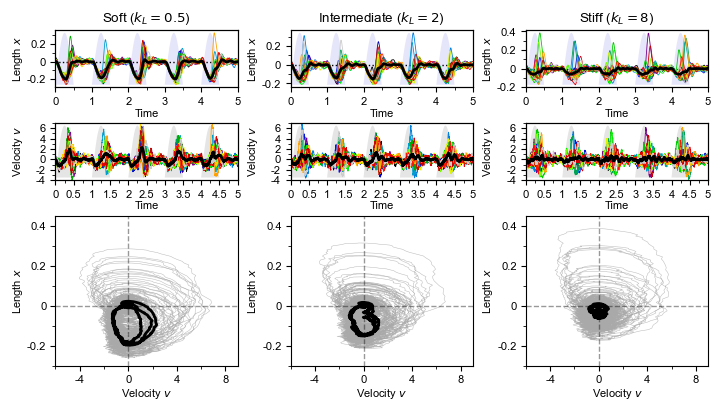

In [19]:
# Plotting results
mosaic = """
ABC
DEF
GHI
GHI
"""
tlim = (0, 5)
xlim = (-6, 9)
ylim = (-0.3, 0.45)

fig, axs = plt.subplot_mosaic(mosaic, figsize=(width_2cols, width_1p5cols*0.8))

axs['A'].set_title(f'Soft ($k_L=0.5$)')
axs['B'].set_title('Intermediate ($k_L=2$)')
axs['C'].set_title('Stiff ($k_L=8$)')

plot_overlay_length(axs['A'], model_soft, tlim=tlim)
plot_overlay_length(axs['B'], model_intermediate, tlim=tlim)
plot_overlay_length(axs['C'], model_stiff, tlim=tlim)

plot_overlay_velocity(axs['D'], model_soft, tlim=tlim)
plot_overlay_velocity(axs['E'], model_intermediate, tlim=tlim)
plot_overlay_velocity(axs['F'], model_stiff, tlim=tlim)

plot_phase_space(axs['G'], model_soft, x_lim=xlim, y_lim=ylim)
plot_phase_space(axs['H'], model_intermediate, x_lim=xlim, y_lim=ylim )
plot_phase_space(axs['I'], model_stiff, x_lim=xlim, y_lim=ylim)

fig.align_labels()
plt.tight_layout(pad=0.4)

fig.savefig(result_folder + 'model_results.png', dpi=400)
